# Customer Churn — Baseline Modeling
- **Owner:** Mohamed Mahmoud
- **Notebook:** 03_mahmoud_modeling_baseline.ipynb
- **Project:** Customer Churn Prediction and Analysis

| ARTIFACT CONTRACT | |
| :--- | :--- |
| **INPUT** | `data/cleaned/processed_telco.csv` |
| **OUTPUTS** | `models/logistic_regression_pipeline.pkl`<br>`models/random_forest_pipeline.pkl`<br>`reports/baseline_model_comparison.md`<br>`assets/plots/models/*.png` |
| **NEXT** | `04_ali_xgboost_optimization.ipynb` |

This notebook trains beginner-friendly baseline churn prediction models using the final processed Phase 2 dataset. It validates the modeling input, creates a stratified train/test split, builds deployment-safe sklearn Pipelines, compares Logistic Regression and Random Forest with churn-focused metrics, validates feature redundancy after the split, and exports trained pipeline artifacts for downstream use.

## Inputs, Outputs, and Critical Rules

**Input:**
- `data/cleaned/processed_telco.csv` — 7,043 rows × 28 columns
- Churn Label is already binary int64 and is the final column
- All feature columns are already numeric

**Outputs:**
- `models/logistic_regression_pipeline.pkl`
- `models/random_forest_pipeline.pkl`
- `reports/baseline_model_comparison.md`
- `assets/plots/models/confusion_matrix_lr.png`
- `assets/plots/models/confusion_matrix_rf.png`
- `assets/plots/models/roc_curve.png`
- `assets/plots/models/feature_importance_rf.png`

> ⚠️ Phase 3 must use only processed_telco.csv. Do not reload raw data, cleaned_telco.csv, or recreate preprocessing/encoding/feature engineering.

> ⚠️ Never use Churn Score, Churn Value, Churn Reason, or CLTV.

> ⚠️ All models must be sklearn Pipelines. Logistic Regression is scaled inside its Pipeline. Random Forest is not scaled. No SMOTE, no resampling, no class_weight balancing, no threshold optimization.

**Metric priority:**
1. Recall
2. F1-score
3. ROC-AUC
4. Precision
5. Accuracy

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print(" Libraries loaded successfully.")

 Libraries loaded successfully.


## 2. Configuration

In [2]:
# ── Paths ────────────────────────────────────────────
# ?? Project root discovery ?????????????????????????????
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    candidate_root = PROJECT_ROOT.parent
    if (candidate_root / "data").exists() and (candidate_root / "notebooks").exists():
        PROJECT_ROOT = candidate_root

if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Could not locate project root containing the data directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from runtime_audit_utils import backup_if_overwriting, record_regeneration_step

PROCESSED_DATA_PATH = PROJECT_ROOT / "data/cleaned/processed_telco.csv"
MODELS_PATH         = PROJECT_ROOT / "models"
REPORTS_PATH        = PROJECT_ROOT / "reports"
MODEL_PLOTS_PATH    = PROJECT_ROOT / "assets/plots/models"

LR_MODEL_PATH       = MODELS_PATH / "logistic_regression_pipeline.pkl"
RF_MODEL_PATH       = MODELS_PATH / "random_forest_pipeline.pkl"
FEATURE_SCHEMA_PATH = MODELS_PATH / "feature_schema.pkl"
REPORT_PATH         = REPORTS_PATH / "baseline_model_comparison.md"

CM_LR_PATH          = MODEL_PLOTS_PATH / "confusion_matrix_lr.png"
CM_RF_PATH          = MODEL_PLOTS_PATH / "confusion_matrix_rf.png"
ROC_PATH            = MODEL_PLOTS_PATH / "roc_curve.png"
RF_IMPORTANCE_PATH  = MODEL_PLOTS_PATH / "feature_importance_rf.png"

# ── Constants ─────────────────────────────────────────
RANDOM_STATE        = 42
TARGET_COLUMN       = "Churn Label"
EXPECTED_ROWS       = 7043
EXPECTED_COLS       = 28
TEST_SIZE           = 0.20
VALIDATION_SIZE     = 0.20
VALIDATION_SIZE     = 0.20
POSITIVE_LABEL      = 1
TARGET_RATE_TOL     = 0.005

LEAKAGE_COLUMNS = [
    "Churn Score", "Churn Value", "Churn Reason", "CLTV"
]

EXPECTED_COLUMNS = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Monthly Charges",
    "Total Charges",
    "Tenure_Group",
    "Num_Add_On_Services",
    "Has_Online_Services",
    "Avg_Monthly_Spend",
    "Is_Long_Term_Contract",
    "Internet Service_Fiber optic",
    "Internet Service_No",
    "Payment Method_Credit card (automatic)",
    "Payment Method_Electronic check",
    "Payment Method_Mailed check",
    "Churn Label"
]

REDUNDANCY_FEATURES = [
    "Total Charges",
    "Tenure Months",
    "Avg_Monthly_Spend",
    "Is_Long_Term_Contract"
]

REDUNDANCY_CONTEXT_FEATURES = [
    "Total Charges",
    "Tenure Months",
    "Avg_Monthly_Spend",
    "Is_Long_Term_Contract",
    "Contract",
    "Monthly Charges"
]

# Create output directories
for p in [MODELS_PATH, REPORTS_PATH, MODEL_PLOTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("Configuration complete.")
print(f"Input path: {PROCESSED_DATA_PATH}")
print(f"Model output path: {MODELS_PATH}")
print(f"Report output path: {REPORTS_PATH}")
print(f"Plot output path: {MODEL_PLOTS_PATH}")

Configuration complete.
Input path: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\data\cleaned\processed_telco.csv
Model output path: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models
Report output path: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\reports
Plot output path: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models


## 3. Load Processed Phase 2 Dataset
This notebook reads only the final hardened Phase 2 artifact: `data/cleaned/processed_telco.csv`.

In [3]:
df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtype summary:\n{df.dtypes.value_counts()}")
print(f"\nTarget distribution:\n{df[TARGET_COLUMN].value_counts().sort_index()}")
print(f"\nChurn rate: {df[TARGET_COLUMN].mean():.4f}")
display(df.head(3))

Shape: (7043, 28)

Dtype summary:
int64      25
float64     3
Name: count, dtype: int64

Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 0.2654


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Num_Add_On_Services,Has_Online_Services,Avg_Monthly_Spend,Is_Long_Term_Contract,Internet Service_Fiber optic,Internet Service_No,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Churn Label
0,1,0,0,0,2,1,0,1,1,0,...,2,1,54.08,0,0,0,0,0,1,1
1,0,0,0,1,2,1,0,0,0,0,...,0,0,75.82,0,1,0,0,1,0,1
2,0,0,0,1,8,1,1,0,0,1,...,3,0,102.56,0,1,0,0,1,0,1


###  GATE 1 — Input Validation
_This gate confirms that Phase 3 is using the frozen model-ready Phase 2 export._

In [4]:
gate1_errors = []

# CHECK 1.1 — Correct file path exists
if PROCESSED_DATA_PATH.exists():
    print(f" GATE 1.1 PASS: Found {PROCESSED_DATA_PATH}")
else:
    gate1_errors.append(f" GATE 1.1 FAIL: Missing {PROCESSED_DATA_PATH}")

# CHECK 1.2 — Shape
if df.shape == (EXPECTED_ROWS, EXPECTED_COLS):
    print(f" GATE 1.2 PASS: Shape is {df.shape}")
else:
    gate1_errors.append(
        f" GATE 1.2 FAIL: Expected {(EXPECTED_ROWS, EXPECTED_COLS)}, got {df.shape}"
    )

# CHECK 1.3 — Exact column order
if list(df.columns) == EXPECTED_COLUMNS:
    print(" GATE 1.3 PASS: Column order exactly matches processed_telco.csv contract.")
else:
    gate1_errors.append(" GATE 1.3 FAIL: Column order or schema does not match contract.")
    print("Expected:")
    print(EXPECTED_COLUMNS)
    print("Actual:")
    print(list(df.columns))

# CHECK 1.4 — Target exists, is last, and is binary numeric
target_ok = (
    TARGET_COLUMN in df.columns
    and df.columns[-1] == TARGET_COLUMN
    and pd.api.types.is_numeric_dtype(df[TARGET_COLUMN])
    and set(df[TARGET_COLUMN].dropna().unique()).issubset({0, 1})
)
if target_ok:
    print(" GATE 1.4 PASS: Target is numeric binary 0/1 and remains the last column.")
else:
    gate1_errors.append("  GATE 1.4 FAIL: Target column is missing, misplaced, non-numeric, or non-binary.")

# CHECK 1.5 — Only source Total Charges nulls may remain for pipeline imputation
null_counts = df.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != "Total Charges")]
if unexpected_nulls.empty:
    print(f"  GATE 1.5 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain.")
else:
    gate1_errors.append(f"  GATE 1.5 FAIL: Unexpected null values found: {unexpected_nulls.to_dict()}.")

# CHECK 1.6 — Zero object dtype columns
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
if not object_cols:
    print("  GATE 1.6 PASS: Zero object dtype columns.")
else:
    gate1_errors.append(f"  GATE 1.6 FAIL: Object dtype columns found: {object_cols}")

# CHECK 1.7 — Leakage absence
found_leakage = [c for c in LEAKAGE_COLUMNS if c in df.columns]
if not found_leakage:
    print("  GATE 1.7 PASS: No leakage columns detected.")
else:
    gate1_errors.append(f"  GATE 1.7 FAIL: Leakage columns found: {found_leakage}")

# CHECK 1.8 — Required redundancy features present
missing_redundancy_features = [c for c in REDUNDANCY_FEATURES if c not in df.columns]
if not missing_redundancy_features:
    print("  GATE 1.8 PASS: Required redundancy-validation features are present.")
else:
    gate1_errors.append(
        f"  GATE 1.8 FAIL: Missing redundancy features: {missing_redundancy_features}"
    )

if gate1_errors:
    for err in gate1_errors:
        print(err)
    raise ValueError("  GATE 1 FAILED. Do not continue. Rerun Phase 2 instead of patching Phase 3.")

print("\n GATE 1 COMPLETE — Input validation passed.")

 GATE 1.1 PASS: Found e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\data\cleaned\processed_telco.csv
 GATE 1.2 PASS: Shape is (7043, 28)
 GATE 1.3 PASS: Column order exactly matches processed_telco.csv contract.
 GATE 1.4 PASS: Target is numeric binary 0/1 and remains the last column.
  GATE 1.5 PASS: Only 11 expected Total Charges nulls remain.
  GATE 1.6 PASS: Zero object dtype columns.
  GATE 1.7 PASS: No leakage columns detected.
  GATE 1.8 PASS: Required redundancy-validation features are present.

 GATE 1 COMPLETE — Input validation passed.


## 4. Create Feature Matrix and Target
The feature order is preserved exactly from processed_telco.csv. No columns are randomly reordered and no preprocessing is recreated.

In [5]:
FEATURE_COLUMNS = [c for c in df.columns if c != TARGET_COLUMN]

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

BASELINE_FEATURES = list(X.columns)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of baseline features: {len(BASELINE_FEATURES)}")
print("\nFirst 5 feature columns:")
print(BASELINE_FEATURES[:5])
print("\nLast 5 feature columns:")
print(BASELINE_FEATURES[-5:])

Feature matrix shape: (7043, 27)
Target shape: (7043,)
Number of baseline features: 27

First 5 feature columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months']

Last 5 feature columns:
['Internet Service_Fiber optic', 'Internet Service_No', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


## 5. Stratified Train/Test Split
The split uses stratify=y and random_state=42 to preserve the churn ratio.

In [6]:
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

validation_fraction_of_development = VALIDATION_SIZE / (1 - TEST_SIZE)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=validation_fraction_of_development,
    random_state=RANDOM_STATE,
    stratify=y_development
)

print(f"X_train shape:       {X_train.shape}")
print(f"X_validation shape:  {X_validation.shape}")
print(f"X_test shape:        {X_test.shape}")

split_summary = pd.DataFrame({
    "Dataset": ["Full", "Train", "Validation", "Untouched Test"],
    "Rows": [len(y), len(y_train), len(y_validation), len(y_test)],
    "Class_0_Count": [
        int((y == 0).sum()),
        int((y_train == 0).sum()),
        int((y_validation == 0).sum()),
        int((y_test == 0).sum())
    ],
    "Class_1_Count": [
        int((y == 1).sum()),
        int((y_train == 1).sum()),
        int((y_validation == 1).sum()),
        int((y_test == 1).sum())
    ],
    "Churn_Rate": [
        y.mean(),
        y_train.mean(),
        y_validation.mean(),
        y_test.mean()
    ]
})

display(split_summary)


X_train shape:       (4225, 27)
X_validation shape:  (1409, 27)
X_test shape:        (1409, 27)


,Dataset,Rows,Class_0_Count,Class_1_Count,Churn_Rate
0,Full,7043,5174,1869,0.265370
1,Train,4225,3104,1121,0.265325
2,Validation,1409,1035,374,0.265436
3,Untouched Test,1409,1035,374,0.265436


###  GATE 2 — Split Validation
_This gate confirms that the split is stratified, reproducible, and schema-stable._

In [7]:
gate2_errors = []

# CHECK 2.1 — Expected split sizes
if len(X_train) + len(X_validation) + len(X_test) == EXPECTED_ROWS:
    print(f" GATE 2.1 PASS: train={len(X_train)}, validation={len(X_validation)}, untouched test={len(X_test)}. Total preserved.")
else:
    gate2_errors.append("  GATE 2.1 FAIL: Three-way split does not preserve all rows.")

# CHECK 2.2 — Feature order preserved
if all(list(frame.columns) == BASELINE_FEATURES for frame in [X_train, X_validation, X_test]):
    print("  GATE 2.2 PASS: Feature order preserved in train, validation, and untouched test sets.")
else:
    gate2_errors.append("  GATE 2.2 FAIL: Feature order changed after split.")

# CHECK 2.3 — Target distribution preserved by stratification
full_rate = y.mean()
rates = {"Train": y_train.mean(), "Validation": y_validation.mean(), "Untouched Test": y_test.mean()}
if all(abs(rate - full_rate) <= TARGET_RATE_TOL for rate in rates.values()):
    print("  GATE 2.3 PASS: Churn rate preserved by deterministic stratification.")
else:
    gate2_errors.append(f"  GATE 2.3 FAIL: Churn rate drift too large: {rates}")

# CHECK 2.4 — No leakage columns in split data
split_leakage = [c for c in LEAKAGE_COLUMNS if c in X_train.columns or c in X_validation.columns or c in X_test.columns]
if not split_leakage:
    print("  GATE 2.4 PASS: No leakage columns in split features.")
else:
    gate2_errors.append(f"  GATE 2.4 FAIL: Leakage columns found after split: {split_leakage}")

# CHECK 2.5 — No target leakage into X
if all(TARGET_COLUMN not in frame.columns for frame in [X_train, X_validation, X_test]):
    print("  GATE 2.5 PASS: Target column is absent from all feature matrices.")
else:
    gate2_errors.append("  GATE 2.5 FAIL: Target column found in a feature matrix.")

if gate2_errors:
    for err in gate2_errors:
        print(err)
    raise ValueError("  GATE 2 FAILED. Recreate the deterministic three-way split.")

print("\n GATE 2 COMPLETE — Three-way split validation passed.")


 GATE 2.1 PASS: train=4225, validation=1409, untouched test=1409. Total preserved.
  GATE 2.2 PASS: Feature order preserved in train, validation, and untouched test sets.
  GATE 2.3 PASS: Churn rate preserved by deterministic stratification.
  GATE 2.4 PASS: No leakage columns in split features.
  GATE 2.5 PASS: Target column is absent from all feature matrices.

 GATE 2 COMPLETE — Three-way split validation passed.


## 6. Post-Split Redundancy and Multicollinearity Review
This analysis uses X_train only to avoid exploratory leakage from the test set.
The required Phase 3 redundancy features are Total Charges, Tenure Months,
Avg_Monthly_Spend, and Is_Long_Term_Contract.

In [8]:
redundancy_corr = X_train[REDUNDANCY_CONTEXT_FEATURES].corr().round(3)

print("Training-only correlation matrix for redundancy context features:")
display(redundancy_corr)

high_corr_pairs = []
corr_abs = redundancy_corr.abs()
for i, col_a in enumerate(corr_abs.columns):
    for col_b in corr_abs.columns[i + 1:]:
        corr_value = corr_abs.loc[col_a, col_b]
        if corr_value >= 0.80:
            high_corr_pairs.append({
                "Feature_A": col_a,
                "Feature_B": col_b,
                "Abs_Correlation": corr_value
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

print("\nHigh-correlation pairs on X_train only (|r| >= 0.80):")
if high_corr_pairs_df.empty:
    print("No pairs exceeded the high-correlation threshold.")
else:
    display(high_corr_pairs_df)

print("\nRequired redundancy features confirmed:")
for feature in REDUNDANCY_FEATURES:
    print(f"  - {feature}")

print("\nInterpretation notes:")
print("- Total Charges and Tenure Months are expected to be highly correlated.")
print("- Avg_Monthly_Spend is derived from Total Charges / Tenure Months.")
print("- Is_Long_Term_Contract is derived from Contract.")
print("- Final performance impact will be tested with feature-set variants after the baseline pipelines are defined.")

Training-only correlation matrix for redundancy context features:


,Total Charges,Tenure Months,Avg_Monthly_Spend,Is_Long_Term_Contract,Contract,Monthly Charges
Total Charges,1.000,0.834,0.651,0.458,0.461,0.650
Tenure Months,0.834,1.000,0.260,0.653,0.677,0.259
Avg_Monthly_Spend,0.651,0.260,1.000,-0.052,-0.064,0.996
Is_Long_Term_Contract,0.458,0.653,-0.052,1.000,0.917,-0.054
Contract,0.461,0.677,-0.064,0.917,1.000,-0.066
Monthly Charges,0.650,0.259,0.996,-0.054,-0.066,1.000



High-correlation pairs on X_train only (|r| >= 0.80):


,Feature_A,Feature_B,Abs_Correlation
0,Total Charges,Tenure Months,0.834
1,Avg_Monthly_Spend,Monthly Charges,0.996
2,Is_Long_Term_Contract,Contract,0.917



Required redundancy features confirmed:
  - Total Charges
  - Tenure Months
  - Avg_Monthly_Spend
  - Is_Long_Term_Contract

Interpretation notes:
- Total Charges and Tenure Months are expected to be highly correlated.
- Avg_Monthly_Spend is derived from Total Charges / Tenure Months.
- Is_Long_Term_Contract is derived from Contract.
- Final performance impact will be tested with feature-set variants after the baseline pipelines are defined.


## 7. Build Baseline sklearn Pipelines
Logistic Regression receives StandardScaler inside the Pipeline. Random Forest
is left unscaled because tree-based models do not require scaling.

In [9]:
lr_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight=None
    ))
])

rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=1,
        class_weight=None
    ))
])

pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline
}

print(" Baseline pipelines defined with training-only median imputation.")
for name, pipe in pipelines.items():
    print(f"\n{name}")
    print(pipe)


 Baseline pipelines defined with training-only median imputation.

Logistic Regression
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

Random Forest
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestClassifier(n_jobs=1, random_state=42))])


###  GATE 3 — Pipeline Validation
_This gate confirms that all models are sklearn Pipelines and preprocessing is inside the correct Pipeline only._

In [10]:
gate3_errors = []

# CHECK 3.1 — All models are sklearn Pipelines
for name, pipe in pipelines.items():
    if isinstance(pipe, Pipeline):
        print(f"  GATE 3.1 PASS: {name} is an sklearn Pipeline.")
    else:
        gate3_errors.append(f"  GATE 3.1 FAIL: {name} is not an sklearn Pipeline.")

# CHECK 3.2 — All pipelines own median imputation
for name, pipe in pipelines.items():
    if "imputer" in pipe.named_steps and isinstance(pipe.named_steps["imputer"], SimpleImputer):
        print(f"  GATE 3.2 PASS: {name} includes training-only median imputation.")
    else:
        gate3_errors.append(f"  GATE 3.2 FAIL: {name} is missing SimpleImputer.")

# CHECK 3.3 — Logistic Regression has StandardScaler
lr_step_names = list(lr_pipeline.named_steps.keys())
if "scaler" in lr_pipeline.named_steps and isinstance(lr_pipeline.named_steps["scaler"], StandardScaler):
    print("  GATE 3.3 PASS: Logistic Regression pipeline includes StandardScaler.")
else:
    gate3_errors.append("  GATE 3.3 FAIL: Logistic Regression pipeline is missing StandardScaler.")

# CHECK 3.3 — Logistic Regression final estimator is LogisticRegression
if isinstance(lr_pipeline.named_steps.get("model"), LogisticRegression):
    print("  GATE 3.3 PASS: Logistic Regression final estimator is correct.")
else:
    gate3_errors.append("  GATE 3.3 FAIL: Logistic Regression final estimator is wrong.")

# CHECK 3.4 — Random Forest has no scaler
rf_has_scaler = any(isinstance(step, StandardScaler) for _, step in rf_pipeline.steps)
if not rf_has_scaler:
    print("  GATE 3.4 PASS: Random Forest pipeline does not include scaling.")
else:
    gate3_errors.append("  GATE 3.4 FAIL: Random Forest pipeline contains a scaler.")

# CHECK 3.5 — Random Forest final estimator is RandomForestClassifier
if isinstance(rf_pipeline.named_steps.get("model"), RandomForestClassifier):
    print("  GATE 3.5 PASS: Random Forest final estimator is correct.")
else:
    gate3_errors.append("  GATE 3.5 FAIL: Random Forest final estimator is wrong.")

# CHECK 3.6 — No class balancing configured
if lr_pipeline.named_steps["model"].class_weight is None and rf_pipeline.named_steps["model"].class_weight is None:
    print("  GATE 3.6 PASS: No class_weight balancing is configured.")
else:
    gate3_errors.append("  GATE 3.6 FAIL: class_weight balancing is configured, which is forbidden in Phase 3.")

if gate3_errors:
    for err in gate3_errors:
        print(err)
    raise ValueError("  GATE 3 FAILED. Fix pipeline definitions before training.")

print("\n GATE 3 COMPLETE — Pipeline validation passed.")

  GATE 3.1 PASS: Logistic Regression is an sklearn Pipeline.
  GATE 3.1 PASS: Random Forest is an sklearn Pipeline.
  GATE 3.2 PASS: Logistic Regression includes training-only median imputation.
  GATE 3.2 PASS: Random Forest includes training-only median imputation.
  GATE 3.3 PASS: Logistic Regression pipeline includes StandardScaler.
  GATE 3.3 PASS: Logistic Regression final estimator is correct.
  GATE 3.4 PASS: Random Forest pipeline does not include scaling.
  GATE 3.5 PASS: Random Forest final estimator is correct.
  GATE 3.6 PASS: No class_weight balancing is configured.

 GATE 3 COMPLETE — Pipeline validation passed.


## 8. Train Official Baseline Models
Both official baseline models are trained on the preserved full Phase 2 feature schema.
Redundancy-controlled variants are evaluated later for analysis, not exported as final artifacts.

In [11]:
trained_models = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_train[BASELINE_FEATURES], y_train)
    trained_models[name] = fitted_pipe
    print(f" {name} training complete.")

Training Logistic Regression...
 Logistic Regression training complete.
Training Random Forest...
 Random Forest training complete.


###  GATE 4 — Training Validation
_This gate confirms that the fitted Pipelines can predict probabilities and preserve the training schema._

In [12]:
gate4_errors = []
model_predictions = {}

for name, pipe in trained_models.items():
    print(f"\nValidating {name}...")

    # CHECK 4.1 — Final estimator is fitted and has classes_
    final_model = pipe.named_steps["model"]
    if hasattr(final_model, "classes_") and list(final_model.classes_) == [0, 1]:
        print(f"  GATE 4.1 PASS: {name} fitted with classes [0, 1].")
    else:
        gate4_errors.append(f"  GATE 4.1 FAIL: {name} does not appear fitted correctly.")

    # CHECK 4.2 — Pipeline captured feature names
    if hasattr(pipe, "feature_names_in_"):
        if list(pipe.feature_names_in_) == BASELINE_FEATURES:
            print(f"  GATE 4.2 PASS: {name} feature schema captured and ordered correctly.")
        else:
            gate4_errors.append(f"  GATE 4.2 FAIL: {name} feature schema mismatched.")
    else:
        print(f" GATE 4.2 WARNING: {name} lacks feature_names_in_. Skipping strict schema order check.")

    # CHECK 4.3 — Predictions work
    y_pred = pipe.predict(X_validation[BASELINE_FEATURES])
    if len(y_pred) == len(y_validation):
        print(f"  GATE 4.3 PASS: {name} predictions generated for all validation rows.")
    else:
        gate4_errors.append(f"  GATE 4.3 FAIL: {name} prediction length mismatch.")

    # CHECK 4.4 — Probabilities work
    y_proba = pipe.predict_proba(X_validation[BASELINE_FEATURES])[:, 1]
    if len(y_proba) == len(y_validation) and np.all((y_proba >= 0) & (y_proba <= 1)):
        print(f"  GATE 4.4 PASS: {name} churn probabilities are valid.")
    else:
        gate4_errors.append(f"  GATE 4.4 FAIL: {name} probability output invalid.")

    model_predictions[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }

if gate4_errors:
    for err in gate4_errors:
        print(err)
    raise ValueError("  GATE 4 FAILED. Do not evaluate or export invalid models.")

print("\n GATE 4 COMPLETE — Training validation passed.")


Validating Logistic Regression...
  GATE 4.1 PASS: Logistic Regression fitted with classes [0, 1].
  GATE 4.2 PASS: Logistic Regression feature schema captured and ordered correctly.
  GATE 4.3 PASS: Logistic Regression predictions generated for all validation rows.
  GATE 4.4 PASS: Logistic Regression churn probabilities are valid.

Validating Random Forest...
  GATE 4.1 PASS: Random Forest fitted with classes [0, 1].
  GATE 4.2 PASS: Random Forest feature schema captured and ordered correctly.
  GATE 4.3 PASS: Random Forest predictions generated for all validation rows.
  GATE 4.4 PASS: Random Forest churn probabilities are valid.

 GATE 4 COMPLETE — Training validation passed.


## 9. Baseline Model Evaluation
Because this is a churn prediction problem, model comparison prioritizes recall, then F1-score, then ROC-AUC, precision, and accuracy.

>  **NOTE**: Future work may compare against a DummyClassifier baseline for academic benchmarking.

In [13]:
def evaluate_predictions(model_name, y_true, y_pred, y_proba):
    return {
        "Model": model_name,
        "Recall": recall_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred, pos_label=POSITIVE_LABEL, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

metrics_rows = []
classification_reports = {}

for name, preds in model_predictions.items():
    metrics_rows.append(
        evaluate_predictions(name, y_validation, preds["y_pred"], preds["y_proba"])
    )
    classification_reports[name] = classification_report(
        y_validation,
        preds["y_pred"],
        target_names=["Not Churned", "Churned"],
        zero_division=0
    )

metrics_df = (
    pd.DataFrame(metrics_rows)
    .sort_values(["Recall", "F1", "ROC_AUC", "Precision", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(metrics_df.style.format({
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Accuracy": "{:.4f}"
}))

for name, report in classification_reports.items():
    print(f"\n=== Classification Report: {name} ===")
    print(report)

,Model,Recall,F1,ROC_AUC,Precision,Accuracy
0,Logistic Regression,0.5695,0.6192,0.8499,0.6783,0.8141
1,Random Forest,0.4866,0.5482,0.8334,0.6276,0.7871



=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

 Not Churned       0.85      0.90      0.88      1035
     Churned       0.68      0.57      0.62       374

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409


=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

 Not Churned       0.83      0.90      0.86      1035
     Churned       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## 10. Confusion Matrix Plots
Confusion matrices show how many churned customers each model catches or misses.

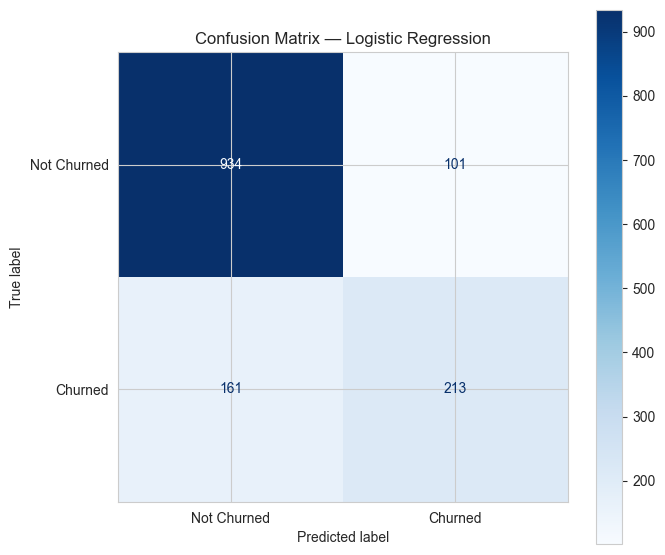

 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\confusion_matrix_lr.png


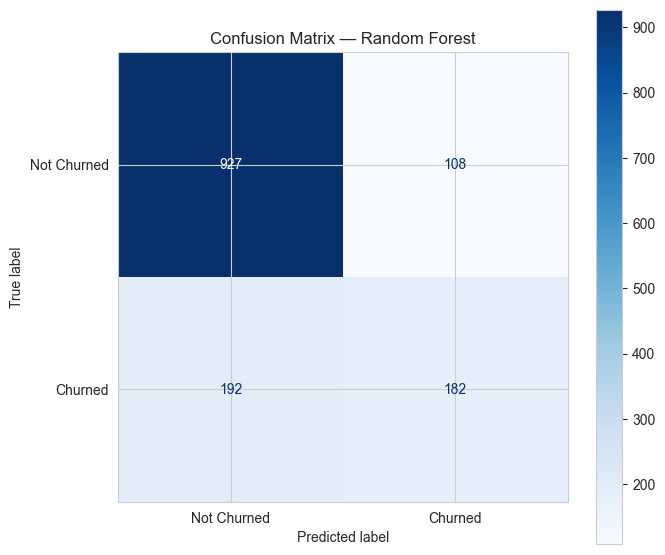

 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\confusion_matrix_rf.png


In [14]:
confusion_plot_specs = [
    ("Logistic Regression", CM_LR_PATH, "Confusion Matrix — Logistic Regression"),
    ("Random Forest", CM_RF_PATH, "Confusion Matrix — Random Forest")
]

for model_name, output_path, title in confusion_plot_specs:
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_validation,
        model_predictions[model_name]["y_pred"],
        display_labels=["Not Churned", "Churned"],
        cmap="Blues",
        values_format="d",
        ax=ax
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f" Saved: {output_path}")

## 11. ROC Curve
The ROC curve compares ranking quality across the two baseline models.

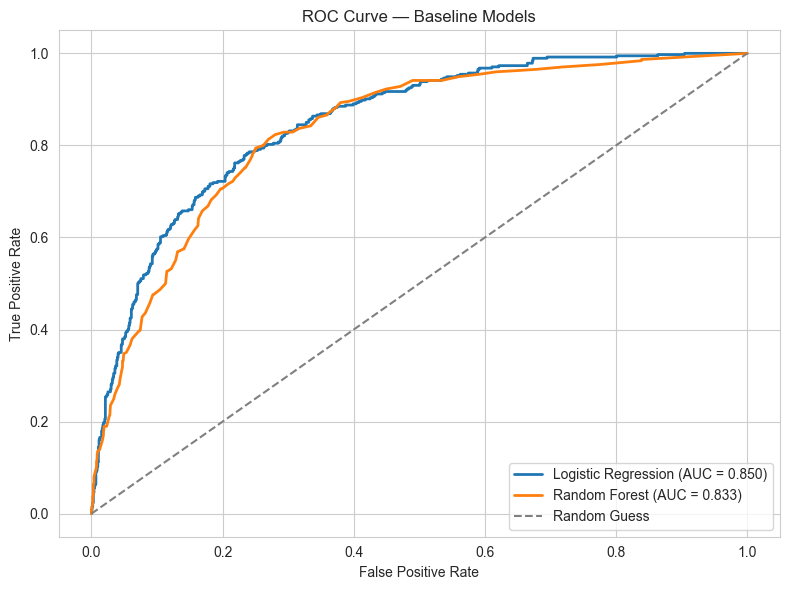

 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\roc_curve.png


In [15]:
plt.figure(figsize=(8, 6))

roc_auc_values = {}
for model_name, preds in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_validation, preds["y_proba"])
    roc_auc = auc(fpr, tpr)
    roc_auc_values[model_name] = roc_auc
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve — Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f" Saved: {ROC_PATH}")

## 12. Post-Split Feature Redundancy Validation
These experiments validate whether keeping the known redundant features helps
or harms model performance. The split is already fixed, so this does not leak
test information into preprocessing. These variant models are analysis-only
and are not exported as final Phase 3 artifacts.

In [16]:
feature_sets = {
    "all_features": BASELINE_FEATURES,
    "drop_total_charges": [c for c in BASELINE_FEATURES if c != "Total Charges"],
    "drop_tenure_months": [c for c in BASELINE_FEATURES if c != "Tenure Months"],
    "drop_avg_monthly_spend": [c for c in BASELINE_FEATURES if c != "Avg_Monthly_Spend"],
    "drop_is_long_term_contract": [c for c in BASELINE_FEATURES if c != "Is_Long_Term_Contract"],
    "drop_derived_redundant": [
        c for c in BASELINE_FEATURES
        if c not in ["Avg_Monthly_Spend", "Is_Long_Term_Contract"]
    ],
    "drop_financial_contract_redundant_combo": [
        c for c in BASELINE_FEATURES
        if c not in ["Total Charges", "Avg_Monthly_Spend", "Is_Long_Term_Contract"]
    ]
}

def fit_and_score_variant(model_name, base_pipeline, feature_set_name, feature_cols):
    pipe = clone(base_pipeline)
    pipe.fit(X_train[feature_cols], y_train)
    pred = pipe.predict(X_validation[feature_cols])
    proba = pipe.predict_proba(X_validation[feature_cols])[:, 1]
    scores = evaluate_predictions(model_name, y_validation, pred, proba)
    scores["Feature_Set"] = feature_set_name
    scores["Feature_Count"] = len(feature_cols)
    scores["Dropped_Features"] = ", ".join([c for c in BASELINE_FEATURES if c not in feature_cols]) or "None"
    return scores

redundancy_results = []

for feature_set_name, feature_cols in feature_sets.items():
    for model_name, base_pipeline in pipelines.items():
        redundancy_results.append(
            fit_and_score_variant(model_name, base_pipeline, feature_set_name, feature_cols)
        )

redundancy_results_df = (
    pd.DataFrame(redundancy_results)
    [["Model", "Feature_Set", "Feature_Count", "Dropped_Features", "Recall", "F1", "ROC_AUC", "Precision", "Accuracy"]]
    .sort_values(["Model", "Recall", "F1", "ROC_AUC", "Precision", "Accuracy"], ascending=[True, False, False, False, False, False])
    .reset_index(drop=True)
)

display(redundancy_results_df.style.format({
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Accuracy": "{:.4f}"
}))

print("Redundancy validation interpretation:")
print("- Compare all_features against feature sets that remove each risky feature.")
print("- Prefer Recall first, then F1, then ROC-AUC.")
print("- Do not modify processed_telco.csv based on these results.")
print("- Use this evidence in the report and for Phase 4 discussion.")

,Model,Feature_Set,Feature_Count,Dropped_Features,Recall,F1,ROC_AUC,Precision,Accuracy
0,Logistic Regression,drop_avg_monthly_spend,26,Avg_Monthly_Spend,0.5722,0.6212,0.8499,0.6794,0.8148
1,Logistic Regression,drop_derived_redundant,25,"Avg_Monthly_Spend, Is_Long_Term_Contract",0.5695,0.6192,0.8501,0.6783,0.8141
2,Logistic Regression,all_features,27,None,0.5695,0.6192,0.8499,0.6783,0.8141
3,Logistic Regression,drop_is_long_term_contract,26,Is_Long_Term_Contract,0.5695,0.6183,0.8499,0.6762,0.8133
4,Logistic Regression,drop_financial_contract_redundant_combo,24,"Total Charges, Avg_Monthly_Spend, Is_Long_Term_Contract",0.5668,0.6172,0.8494,0.6773,0.8133
5,Logistic Regression,drop_tenure_months,26,Tenure Months,0.5588,0.6174,0.8495,0.6898,0.8162
6,Logistic Regression,drop_total_charges,26,Total Charges,0.5588,0.6120,0.8491,0.6764,0.8119
7,Random Forest,drop_financial_contract_redundant_combo,24,"Total Charges, Avg_Monthly_Spend, Is_Long_Term_Contract",0.4947,0.5564,0.8302,0.6357,0.7906
8,Random Forest,drop_total_charges,26,Total Charges,0.4866,0.5540,0.8321,0.6431,0.7921
9,Random Forest,all_features,27,None,0.4866,0.5482,0.8334,0.6276,0.7871


Redundancy validation interpretation:
- Compare all_features against feature sets that remove each risky feature.
- Prefer Recall first, then F1, then ROC-AUC.
- Do not modify processed_telco.csv based on these results.
- Use this evidence in the report and for Phase 4 discussion.


## 13. Random Forest Feature Importance
Feature importance is shown for interpretability only. With correlated variables, Random Forest may split importance across redundant predictors.

,Feature,Importance
0,Total Charges,0.128458
1,Avg_Monthly_Spend,0.127793
2,Monthly Charges,0.126157
3,Tenure Months,0.118096
4,Is_Long_Term_Contract,0.057149
5,Contract,0.050071
6,Tenure_Group,0.035887
7,Internet Service_Fiber optic,0.035320
8,Dependents,0.033493
9,Num_Add_On_Services,0.028854


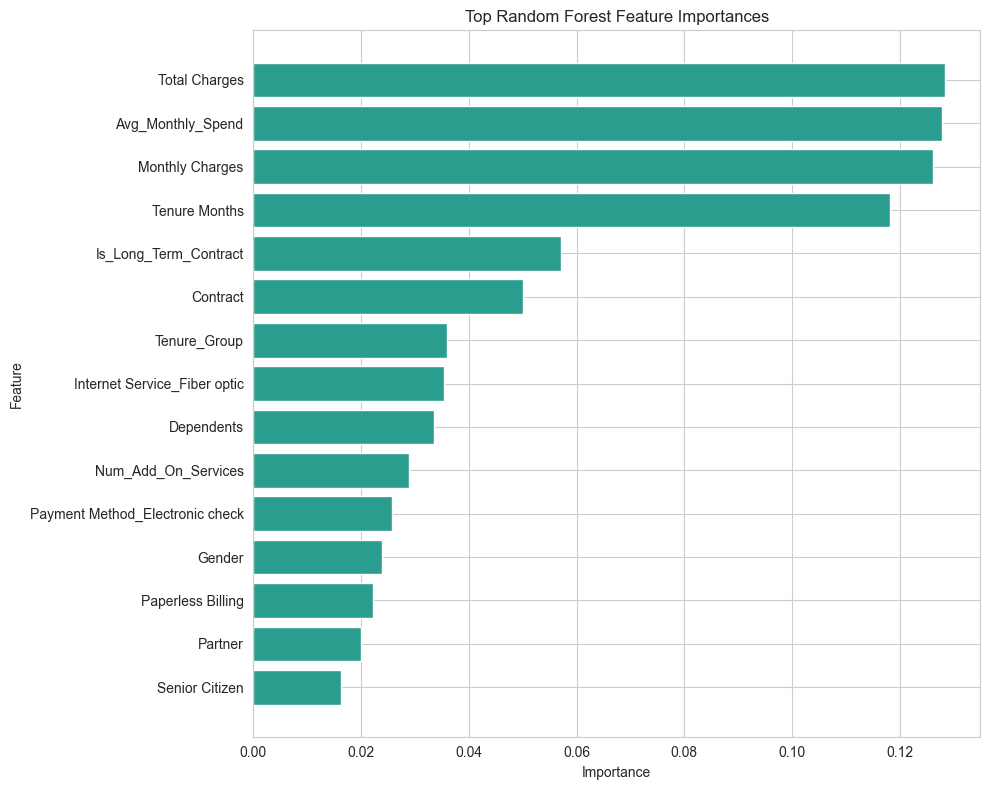

 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\feature_importance_rf.png

 Reminder: importance can be unstable when correlated or derived features exist.


In [17]:
rf_model = trained_models["Random Forest"].named_steps["model"]

rf_importance_df = (
    pd.DataFrame({
        "Feature": BASELINE_FEATURES,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_df.head(15))

top_n = min(15, len(rf_importance_df))
plot_df = rf_importance_df.head(top_n).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["Feature"], plot_df["Importance"], color="#2a9d8f")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(RF_IMPORTANCE_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f" Saved: {RF_IMPORTANCE_PATH}")
print("\n Reminder: importance can be unstable when correlated or derived features exist.")

## 14. Export Trained Pipeline Artifacts
These artifacts include the fitted sklearn Pipeline objects. Logistic Regression includes its scaler inside the pipeline.

In [18]:
backup_if_overwriting(LR_MODEL_PATH, PROJECT_ROOT, "Logistic Regression model")
backup_if_overwriting(RF_MODEL_PATH, PROJECT_ROOT, "Random Forest model")
backup_if_overwriting(FEATURE_SCHEMA_PATH, PROJECT_ROOT, "feature schema")
joblib.dump(trained_models["Logistic Regression"], LR_MODEL_PATH)
joblib.dump(trained_models["Random Forest"], RF_MODEL_PATH)
joblib.dump(BASELINE_FEATURES, FEATURE_SCHEMA_PATH)

print(f" Saved: {LR_MODEL_PATH}")
print(f" Saved: {RF_MODEL_PATH}")
print(f" Saved: {FEATURE_SCHEMA_PATH}")
record_regeneration_step(
    PROJECT_ROOT,
    "03_modeling_baseline",
    "notebooks/03_mahmoud_modeling_baseline.ipynb",
    [LR_MODEL_PATH, RF_MODEL_PATH, FEATURE_SCHEMA_PATH],
)


 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models\logistic_regression_pipeline.pkl
 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models\random_forest_pipeline.pkl
 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models\feature_schema.pkl


## 15. Export Baseline Model Comparison Report
The report documents model metrics, split validation, redundancy findings, and Streamlit schema notes.

In [19]:
def markdown_table(df_to_render, float_cols=None):
    table = df_to_render.copy()
    if float_cols:
        for col in float_cols:
            if col in table.columns:
                table[col] = table[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")
    table = table.astype(str)

    def clean_cell(value):
        return str(value).replace("|", "/").replace("\n", " ")

    headers = [clean_cell(col) for col in table.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |"
    ]

    for _, row in table.iterrows():
        lines.append("| " + " | ".join(clean_cell(row[col]) for col in table.columns) + " |")

    return "\n".join(lines)

metric_cols = ["Recall", "F1", "ROC_AUC", "Precision", "Accuracy"]

report_lines = []
report_lines.append("# Phase 3 Baseline Model Comparison")
report_lines.append("")
report_lines.append("## Source of Truth")
report_lines.append("- Input used: `data/cleaned/processed_telco.csv`")
report_lines.append("- Shape: 7,043 rows × 28 columns")
report_lines.append("- Target: `Churn Label` where 1 = Churned and 0 = Not Churned")
report_lines.append("- No raw data, cleaned data, preprocessing recreation, encoding recreation, or feature engineering recreation was used.")
report_lines.append("- Leakage columns excluded: `Churn Score`, `Churn Value`, `Churn Reason`, `CLTV`")
report_lines.append("")

report_lines.append("## Split Summary")
report_lines.append(markdown_table(split_summary, float_cols=["Churn_Rate"]))
report_lines.append("")
report_lines.append("Split rule: deterministic 64% train / 16% validation / 20% untouched test using `random_state=42` and `stratify`.")
report_lines.append("")

report_lines.append("## Evaluation Priority")
report_lines.append("1. Recall")
report_lines.append("2. F1-score")
report_lines.append("3. ROC-AUC")
report_lines.append("4. Precision")
report_lines.append("5. Accuracy")
report_lines.append("")

report_lines.append("## Baseline Metrics")
report_lines.append(markdown_table(metrics_df, float_cols=metric_cols))
report_lines.append("")

report_lines.append("## Classification Reports")
for name, report in classification_reports.items():
    report_lines.append(f"### {name}")
    report_lines.append("```text")
    report_lines.append(report)
    report_lines.append("```")
    report_lines.append("")

report_lines.append("## Redundancy and Multicollinearity Validation")
report_lines.append("This analysis was performed after the three-way split and used `X_train` for correlation review. Baseline comparison uses validation only; the untouched test is reserved for Phase 4 final reporting.")
report_lines.append("")
report_lines.append("Required redundancy features evaluated:")
for feature in REDUNDANCY_FEATURES:
    report_lines.append(f"- `{feature}`")
report_lines.append("")

report_lines.append("### Training-Only Correlation Matrix")
report_lines.append(markdown_table(redundancy_corr.reset_index().rename(columns={"index": "Feature"})))
report_lines.append("")

report_lines.append("### High-Correlation Pairs")
if high_corr_pairs_df.empty:
    report_lines.append("No training-set feature pairs exceeded |r| >= 0.80.")
else:
    report_lines.append(markdown_table(high_corr_pairs_df, float_cols=["Abs_Correlation"]))
report_lines.append("")

report_lines.append("### Feature-Set Variant Results")
report_lines.append(markdown_table(redundancy_results_df, float_cols=metric_cols))
report_lines.append("")

all_feature_rows = redundancy_results_df[redundancy_results_df["Feature_Set"] == "all_features"]
report_lines.append("### Redundancy Decision")
report_lines.append("- The official exported Phase 3 baselines are trained on the full processed Phase 2 schema for a stable handoff.")
report_lines.append("- The feature-set variants above show whether removing `Total Charges`, `Tenure Months`, `Avg_Monthly_Spend`, or `Is_Long_Term_Contract` improves or harms Recall/F1/ROC-AUC.")
report_lines.append("- Do not modify `processed_telco.csv`; use this evidence for Phase 4 model comparison and discussion.")
report_lines.append("")

report_lines.append("## Random Forest Feature Importance Note")
report_lines.append("Random Forest feature importance can be unstable when highly correlated or derived features exist, so the plot is interpretive guidance only.")
report_lines.append("")

report_lines.append("- Probability calibration was not performed in Phase 3 and may be evaluated in Phase 4.")
report_lines.append("## Streamlit Compatibility Notes")
report_lines.append("- Saved artifacts are fitted sklearn Pipelines.")
report_lines.append("- Training-only median imputation and Logistic Regression scaling are inside `logistic_regression_pipeline.pkl`.")
report_lines.append("- Random Forest has no scaler.")
report_lines.append("- Future Streamlit inference must provide the same 27 feature columns in the same order.")
report_lines.append("- No manual inference scaling should be implemented.")
report_lines.append("")

report_lines.append("## Exported Artifacts")
report_lines.append("- `models/logistic_regression_pipeline.pkl`")
report_lines.append("- `models/random_forest_pipeline.pkl`")
report_lines.append("- `assets/plots/models/confusion_matrix_lr.png`")
report_lines.append("- `assets/plots/models/confusion_matrix_rf.png`")
report_lines.append("- `assets/plots/models/roc_curve.png`")
report_lines.append("- `assets/plots/models/feature_importance_rf.png`")
report_lines.append("")

report_lines.append("## Final Verdict")
report_lines.append("Phase 3 baseline modeling artifacts are ready for Phase 4 comparison.")

REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"📁 Saved: {REPORT_PATH}")

📁 Saved: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\reports\baseline_model_comparison.md


###  GATE 5 — Export Validation
_This gate reloads saved artifacts and verifies that required plots and report files exist._

In [20]:
gate5_errors = []

required_export_paths = [
    LR_MODEL_PATH,
    RF_MODEL_PATH,
    REPORT_PATH,
    CM_LR_PATH,
    CM_RF_PATH,
    ROC_PATH,
    RF_IMPORTANCE_PATH,
    FEATURE_SCHEMA_PATH
]

# CHECK 5.1 — Required files exist and are non-empty
for path in required_export_paths:
    if path.exists() and path.stat().st_size > 0:
        print(f"  GATE 5.1 PASS: {path} exists and is non-empty.")
    else:
        gate5_errors.append(f"  GATE 5.1 FAIL: {path} missing or empty.")

# CHECK 5.2 — Reload model artifacts
try:
    loaded_lr = joblib.load(LR_MODEL_PATH)
    loaded_rf = joblib.load(RF_MODEL_PATH)
    print("  GATE 5.2 PASS: Model artifacts reloaded successfully.")
except Exception as exc:
    gate5_errors.append(f"  GATE 5.2 FAIL: Could not reload model artifacts: {exc}")
    loaded_lr = None
    loaded_rf = None

# CHECK 5.3 — Reloaded objects are Pipelines
loaded_models = {
    "Logistic Regression": loaded_lr,
    "Random Forest": loaded_rf
}

for name, loaded_model in loaded_models.items():
    if isinstance(loaded_model, Pipeline):
        print(f"  GATE 5.3 PASS: Reloaded {name} is an sklearn Pipeline.")
    else:
        gate5_errors.append(f"  GATE 5.3 FAIL: Reloaded {name} is not an sklearn Pipeline.")

# CHECK 5.4 — Reloaded models can predict from the same schema
sample_X = X_validation[BASELINE_FEATURES].head(5)

for name, loaded_model in loaded_models.items():
    if loaded_model is None:
        continue
    try:
        sample_pred = loaded_model.predict(sample_X)
        sample_proba = loaded_model.predict_proba(sample_X)[:, 1]
        if len(sample_pred) == 5 and len(sample_proba) == 5:
            if hasattr(loaded_model, "feature_names_in_"):
                if list(loaded_model.feature_names_in_) == BASELINE_FEATURES:
                    print(f"  GATE 5.4 PASS: Reloaded {name} predicts with stable schema.")
                else:
                    gate5_errors.append(f"  GATE 5.4 FAIL: Reloaded {name} schema mismatched.")
            else:
                print(f"  GATE 5.4 PASS (with  WARNING): Reloaded {name} predicts successfully but lacks feature_names_in_.")
        else:
            gate5_errors.append(f"  GATE 5.4 FAIL: Reloaded {name} prediction output invalid.")
    except Exception as exc:
        gate5_errors.append(f"  GATE 5.4 FAIL: Reloaded {name} prediction failed: {exc}")

# CHECK 5.6 — Reload feature schema
try:
    loaded_schema = joblib.load(FEATURE_SCHEMA_PATH)
    if loaded_schema == BASELINE_FEATURES:
        print("  GATE 5.6 PASS: Feature schema artifact reloaded and matches BASELINE_FEATURES.")
    else:
        gate5_errors.append("  GATE 5.6 FAIL: Feature schema artifact does not match.")
except Exception as exc:
    gate5_errors.append(f"  GATE 5.6 FAIL: Could not reload feature schema: {exc}")

# CHECK 5.5 — Report includes required sections
if REPORT_PATH.exists():
    report_text = REPORT_PATH.read_text(encoding="utf-8")
    required_report_phrases = [
        "Baseline Metrics",
        "Redundancy and Multicollinearity Validation",
        "Feature-Set Variant Results",
        "Streamlit Compatibility Notes",
        "Final Verdict"
    ]
    missing_phrases = [phrase for phrase in required_report_phrases if phrase not in report_text]
    if not missing_phrases:
        print("  GATE 5.5 PASS: Report contains required sections.")
    else:
        gate5_errors.append(f"  GATE 5.5 FAIL: Report missing sections: {missing_phrases}")

if gate5_errors:
    for err in gate5_errors:
        print(err)
    raise ValueError("  GATE 5 FAILED. Fix exports before handoff.")

print("\n GATE 5 COMPLETE — All Phase 3 exports validated.")
print(" HANDOFF READY → 04_ali_xgboost_optimization.ipynb")

  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models\logistic_regression_pipeline.pkl exists and is non-empty.
  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\models\random_forest_pipeline.pkl exists and is non-empty.
  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\reports\baseline_model_comparison.md exists and is non-empty.
  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\confusion_matrix_lr.png exists and is non-empty.
  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analysis-Project-main\Customer-Churn-Prediction-and-Analysis-Project-main\assets\plots\models\confusion_matrix_rf.png exists and is non-empty.
  GATE 5.1 PASS: e:\Customer-Churn-Prediction-and-Analys

## 16. Summary & Handoff

### What was accomplished in this notebook:
-  Loaded only `data/cleaned/processed_telco.csv`
-  Confirmed the final hardened Phase 2 schema: 7,043 rows × 28 columns
-  Confirmed zero nulls, zero object dtype columns, and no leakage columns
-  Preserved the original 27-feature modeling schema
-  Created a stratified train/test split with `random_state=42`
-  Built Logistic Regression and Random Forest sklearn Pipelines
-  Scaled Logistic Regression inside the Pipeline only
-  Left Random Forest unscaled
-  Trained both baseline models without SMOTE, resampling, class weighting, tuning, or threshold optimization
-  Evaluated models using Recall, F1-score, ROC-AUC, Precision, and Accuracy
-  Generated confusion matrices, ROC curve, and Random Forest feature importance plot
-  Validated redundancy/multicollinearity after train/test split
-  Exported trained pipeline artifacts and baseline comparison report

### Required artifacts exported:
- `models/logistic_regression_pipeline.pkl`
- `models/random_forest_pipeline.pkl`
- `reports/baseline_model_comparison.md`
- `assets/plots/models/confusion_matrix_lr.png`
- `assets/plots/models/confusion_matrix_rf.png`
- `assets/plots/models/roc_curve.png`
- `assets/plots/models/feature_importance_rf.png`

### Redundancy features explicitly evaluated:
- `Total Charges`
- `Tenure Months`
- `Avg_Monthly_Spend`
- `Is_Long_Term_Contract`

### Handoff to Phase 4:
**Next notebook:** `04_ali_xgboost_optimization.ipynb`

Phase 4 may compare XGBoost against these Phase 3 baselines using the same evaluation priority:
1. Recall
2. F1-score
3. ROC-AUC
4. Precision
5. Accuracy

>  Do NOT modify `processed_telco.csv`.
> If schema problems are found, rerun Phase 2 completely and regenerate the official export.

>  Do NOT implement manual inference scaling in Streamlit.
> Scaling for Logistic Regression is already inside the saved Pipeline.